# Evaluación comparativa de arquitecturas convolucionales
**Actividad 2 · Checkpoint 3 · Sistemas de aprendizaje profundo**

Se comparan dos CNN propias y MobileNetV2 preentrenada en ImageNet para clasificar CIFAR-10.
El objetivo es evaluar precisión, F1 macro, sobreajuste, parámetros y costo de entrenamiento.

## Diseño experimental
Se usan 12 000 imágenes de entrenamiento y 3 000 de validación, seleccionadas de forma
estratificada del conjunto oficial de entrenamiento. Las 10 000 imágenes oficiales de prueba
se reservan para la evaluación final. Este presupuesto permite ejecutar el experimento en CPU;
no representa el rendimiento máximo de estas arquitecturas. La semilla es 42.

Los tres modelos usan exactamente las mismas particiones, batch de 128, Adam y hasta 12 épocas,
con selección de pesos por la menor pérdida de validación. El conjunto de prueba no interviene
en la selección. Se realiza una sola ejecución por modelo: las diferencias pequeñas requieren
repetir con más semillas antes de considerarlas concluyentes.

In [1]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("KERAS_HOME", str(__import__("pathlib").Path.cwd() / ".keras"))
import json
import time
import platform
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay
from IPython.display import display, Markdown

SEED = 42
BATCH = 128
EPOCHS = 12
keras.utils.set_random_seed(SEED)
tf.config.threading.set_intra_op_parallelism_threads(8)
tf.config.threading.set_inter_op_parallelism_threads(2)
RESULTS = Path("resultados")
RESULTS.mkdir(exist_ok=True)
print("Python:", platform.python_version(), "TensorFlow:", tf.__version__)
print("Dispositivos:", tf.config.list_physical_devices())

Python: 3.12.14 TensorFlow: 2.21.0


Dispositivos: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## Datos y prevención de fugas
CIFAR-10 contiene imágenes RGB de 32 × 32 y diez clases balanceadas.
Se conservan valores de píxeles entre 0 y 255: cada modelo incorpora su propio escalado.
El aumento de datos solo se activa durante el entrenamiento; validación y prueba no se aumentan.

Entrenamiento 12000 imágenes; por clase: [1200 1200 1200 1200 1200 1200 1200 1200 1200 1200]
Validación 3000 imágenes; por clase: [300 300 300 300 300 300 300 300 300 300]
Prueba 10000 imágenes; por clase: [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]


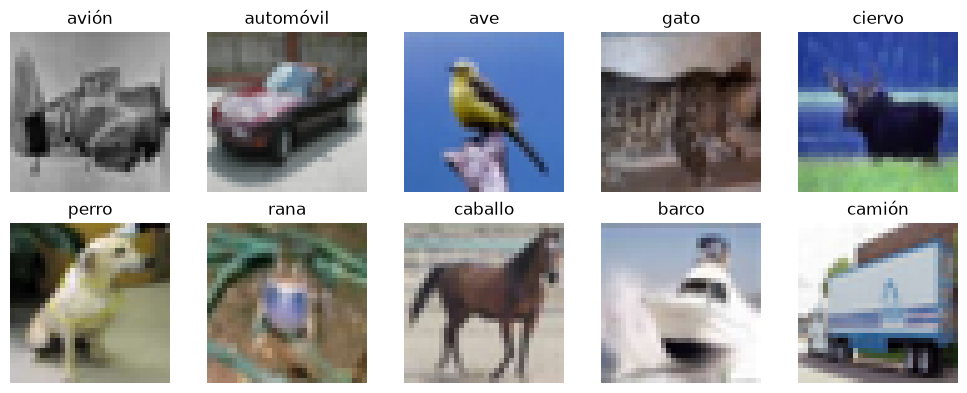

In [2]:
(x_all, y_all), (x_test, y_test) = keras.datasets.cifar10.load_data()
y_all, y_test = y_all.ravel(), y_test.ravel()
idx_train, idx_rest = train_test_split(np.arange(len(y_all)), train_size=12000,
                                      stratify=y_all, random_state=SEED)
idx_val, _ = train_test_split(idx_rest, train_size=3000,
                            stratify=y_all[idx_rest], random_state=SEED)
x_train, y_train = x_all[idx_train], y_all[idx_train]
x_val, y_val = x_all[idx_val], y_all[idx_val]
CLASSES = ["avión", "automóvil", "ave", "gato", "ciervo", "perro", "rana", "caballo", "barco", "camión"]
assert not set(idx_train) & set(idx_val)
for name, y in [("Entrenamiento", y_train), ("Validación", y_val), ("Prueba", y_test)]:
    print(name, len(y), "imágenes; por clase:", np.bincount(y))
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for label, ax in enumerate(axes.flat):
    ax.imshow(x_train[np.flatnonzero(y_train == label)[0]])
    ax.set_title(CLASSES[label]); ax.axis("off")
plt.tight_layout(); plt.show()

def dataset(x, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if training:
        ds = ds.shuffle(len(y), seed=SEED)
    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)
val_ds = dataset(x_val, y_val)
test_ds = dataset(x_test, y_test)

## Arquitecturas y justificación de hiperparámetros

| Modelo | Diseño | Justificación |
|---|---|---|
| CNN básica | Conv 32 → pool → Conv 64 → pool → Flatten → Dense 64 | Referencia de baja profundidad; Flatten conserva posición, pero aumenta los parámetros de la cabeza. |
| CNN profunda | Dos convoluciones por bloque, 32/64/128 filtros, BatchNorm, pooling y GlobalAveragePooling | Mayor capacidad para combinar patrones; GAP reduce la cabeza densa y BatchNorm estabiliza las activaciones. |
| MobileNetV2 | Base ImageNet congelada, entrada 96 × 96, GAP y cabeza de diez clases | Transfer learning reutiliza características aprendidas; convoluciones separables reducen el costo frente a arquitecturas clásicas más grandes. |

Las CNN propias usan filtros 3 × 3, ReLU y padding same, que capturan patrones locales sin
reducir el tamaño antes del pooling 2 × 2. Ambas usan L2=0.0001 y Dropout; la profunda aplica
Dropout creciente (0.15–0.35). Las tres usan reflexión horizontal y traslación de hasta 10 %,
transformaciones razonables para los objetos de CIFAR-10. No se usan inversiones verticales.
Adam con tasa 0.001 es el punto inicial común. ReduceLROnPlateau reduce la tasa ante estancamiento
y EarlyStopping evita continuar sin mejora, restaurando los mejores pesos.

MobileNetV2 requiere píxeles en [-1, 1]; Rescaling(1/127.5, offset=-1) implementa ese escalado.
Se amplía a 96 × 96 para aprovechar los pesos publicados a esa resolución; esto no añade detalle
real. La base se invoca con training=False para mantener sus estadísticas de BatchNorm.
Su preentrenamiento aporta datos y cómputo externos: la comparación evalúa estrategias prácticas,
no un presupuesto total de entrenamiento equivalente.

In [3]:
def augmentation():
    return keras.Sequential([
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomTranslation(0.1, 0.1, seed=SEED + 1),
    ], name="aumento")

def cnn_basica():
    inputs = keras.Input((32, 32, 3))
    x = layers.Rescaling(1 / 255.0)(augmentation()(inputs))
    for filters in (32, 64):
        x = layers.Conv2D(filters, 3, padding="same", activation="relu",
                          kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    return keras.Model(inputs, layers.Dense(10, activation="softmax")(x), name="cnn_basica")

def cnn_profunda():
    inputs = keras.Input((32, 32, 3))
    x = layers.Rescaling(1 / 255.0)(augmentation()(inputs))
    for filters, dropout in [(32, 0.15), (64, 0.25), (128, 0.35)]:
        for _ in range(2):
            x = layers.Conv2D(filters, 3, padding="same", use_bias=False,
                              kernel_regularizer=regularizers.l2(1e-4))(x)
            x = layers.BatchNormalization()(x)
            x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D()(x)
        x = layers.Dropout(dropout)(x)
    x = layers.GlobalAveragePooling2D()(x)
    return keras.Model(inputs, layers.Dense(10, activation="softmax")(x), name="cnn_profunda")

def transfer_mobilenet():
    base = MobileNetV2(include_top=False, weights="imagenet", input_shape=(96, 96, 3))
    base.trainable = False
    inputs = keras.Input((32, 32, 3))
    x = augmentation()(inputs)
    x = layers.Resizing(96, 96)(x)
    x = layers.Rescaling(1 / 127.5, offset=-1)(x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    return keras.Model(inputs, layers.Dense(10, activation="softmax")(x), name="mobilenet_v2")

BUILDERS = {"CNN básica": cnn_basica, "CNN profunda": cnn_profunda,
            "MobileNetV2": transfer_mobilenet}

## Entrenamiento y evaluación
Se reinicia la semilla y se crea un nuevo optimizador, conjunto de entrenamiento y callbacks
para cada modelo. Se guardan los historiales, métricas y predicciones para auditar el reporte.
Los tiempos incluyen únicamente fit, sin descarga de datos/pesos ni evaluación.
La pérdida incluye la penalización L2 donde existe; accuracy y F1 son las métricas de comparación
principal. El mejor modelo se selecciona por accuracy de validación tras restaurar sus pesos.

In [4]:
histories, rows, predictions = {}, [], {}
for name, builder in BUILDERS.items():
    keras.backend.clear_session()
    keras.utils.set_random_seed(SEED)
    model = builder()
    model.summary()
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    callbacks = [
        keras.callbacks.CSVLogger(str(RESULTS / (model.name + "_epocas.csv"))),
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=2, factor=0.5, min_lr=1e-5),
    ]
    start = time.perf_counter()
    history = model.fit(dataset(x_train, y_train, True), validation_data=val_ds,
                        epochs=EPOCHS, callbacks=callbacks, verbose=2)
    seconds = time.perf_counter() - start
    histories[name] = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    val_loss, val_acc = model.evaluate(val_ds, verbose=0)
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    pred = model.predict(test_ds, verbose=0).argmax(axis=1)
    predictions[name] = pred
    rows.append(dict(modelo=name, parametros=model.count_params(),
                     entrenables=sum(int(np.prod(w.shape)) for w in model.trainable_weights),
                     epocas=len(history.history["loss"]),
                     mejor_epoca=int(np.argmin(history.history["val_loss"]) + 1),
                     segundos=seconds, val_accuracy=val_acc, test_accuracy=test_acc,
                     test_f1_macro=f1_score(y_test, pred, average="macro"), test_loss=test_loss))
    pd.DataFrame(rows).to_csv(RESULTS / "comparacion.csv", index=False)
    (RESULTS / "historiales.json").write_text(json.dumps(histories, indent=2), encoding="utf-8")
    np.savez_compressed(RESULTS / "predicciones.npz", y_test=y_test, **predictions)
    print(name, "finalizado:", rows[-1], flush=True)
comparison = pd.DataFrame(rows).set_index("modelo")
display(comparison.round(4))

Model: "cnn_basica"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aumento (Sequential)            │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,250 (1.08 MB)

 Trainable params: 282,250 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

...

94/94 - 20s - 209ms/step - accuracy: 0.8023 - loss: 0.5727 - val_accuracy: 0.8433 - val_loss: 0.4619 - learning_rate: 5.0000e-04


Epoch 12/12


94/94 - 19s - 201ms/step - accuracy: 0.8003 - loss: 0.5626 - val_accuracy: 0.8373 - val_loss: 0.4673 - learning_rate: 5.0000e-04


MobileNetV2 finalizado: {'modelo': 'MobileNetV2', 'parametros': 2270794, 'entrenables': 12810, 'epocas': 12, 'mejor_epoca': 11, 'segundos': 241.9035942000046, 'val_accuracy': 0.8433333039283752, 'test_accuracy': 0.8403000235557556, 'test_f1_macro': 0.8385047899754687, 'test_loss': 0.4543857276439667}


,parametros,entrenables,epocas,mejor_epoca,segundos,val_accuracy,test_accuracy,test_f1_macro,test_loss
modelo,,,,,,,,,
CNN básica,282250,282250,12,10,24.2350,0.5800,0.5784,0.5725,1.2298
CNN profunda,289642,288746,12,10,143.0416,0.6730,0.6714,0.6680,0.9634
MobileNetV2,2270794,12810,12,11,241.9036,0.8433,0.8403,0.8385,0.4544


## Estadística y gráficos
Las curvas permiten detectar estancamiento y separación entre entrenamiento y validación.
El aumento y Dropout están activos en entrenamiento; por ello una accuracy de validación
mayor que la de entrenamiento no implica por sí sola un error. Las matrices de confusión
muestran qué clases presentan dificultades, más allá del promedio global.

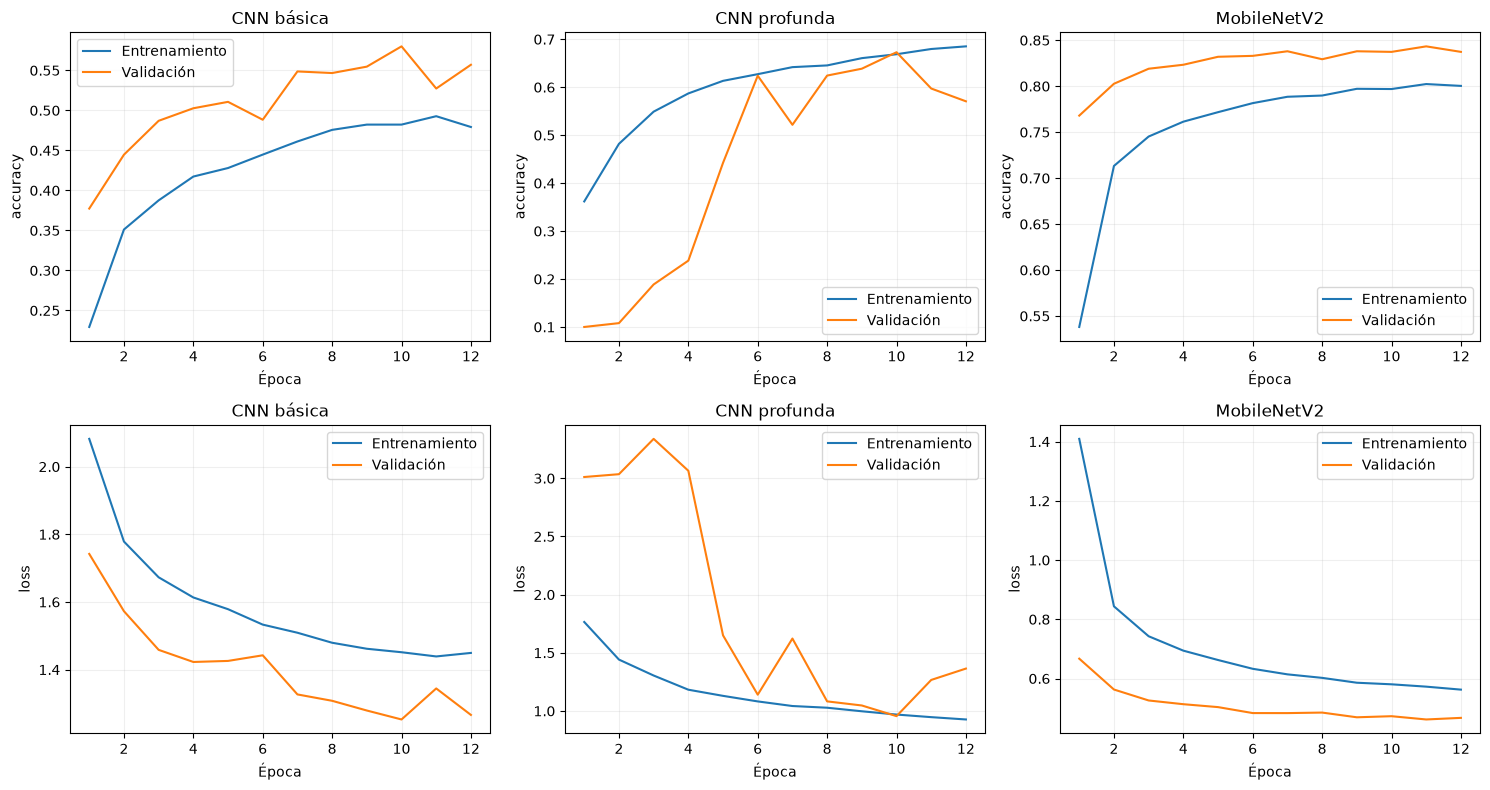

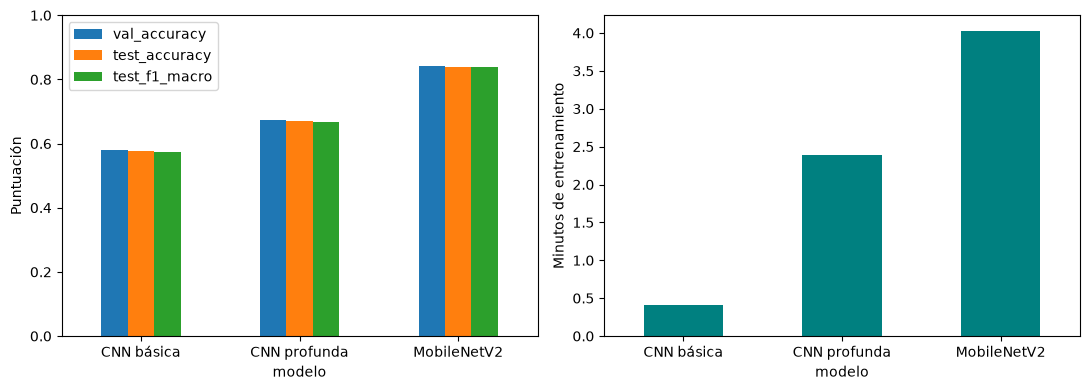

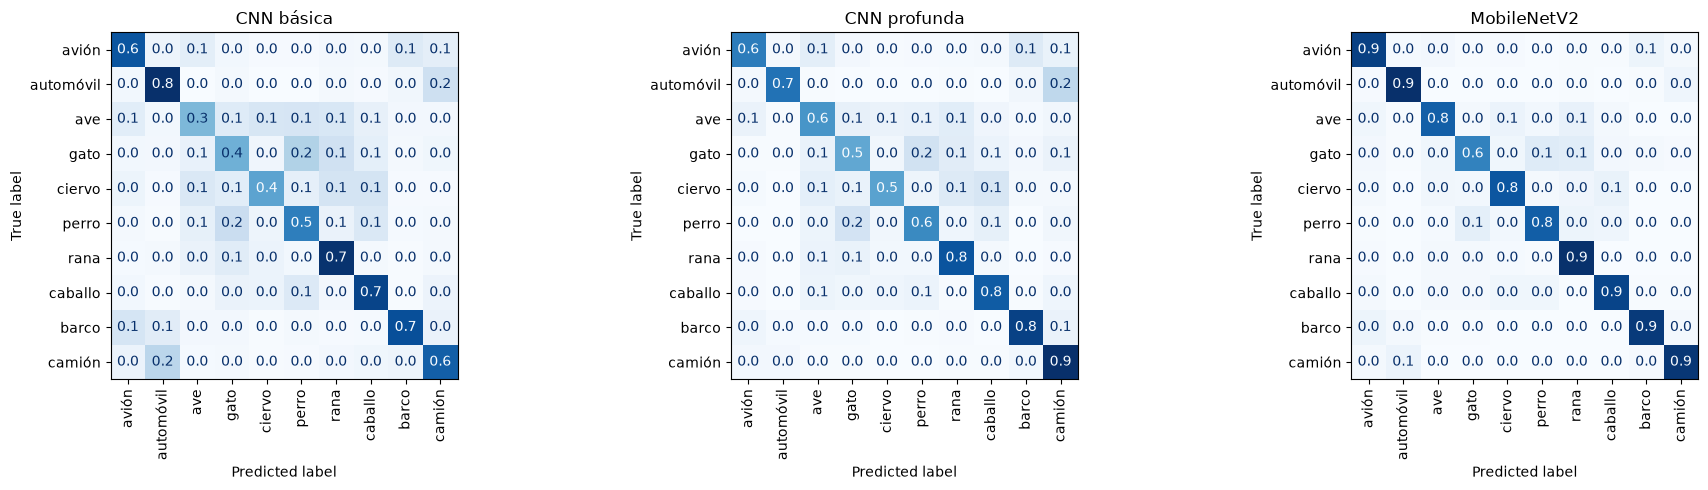

Modelo seleccionado por validación: MobileNetV2
              precision    recall  f1-score   support

       avión      0.833     0.876     0.854      1000
   automóvil      0.905     0.938     0.921      1000
         ave      0.838     0.768     0.801      1000
        gato      0.784     0.639     0.704      1000
      ciervo      0.820     0.801     0.810      1000
       perro      0.790     0.773     0.782      1000
        rana      0.775     0.934     0.847      1000
     caballo      0.850     0.864     0.857      1000
       barco      0.909     0.901     0.905      1000
      camión      0.899     0.909     0.904      1000

    accuracy                          0.840     10000
   macro avg      0.840     0.840     0.839     10000
weighted avg      0.840     0.840     0.839     10000



In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, (name, h) in enumerate(histories.items()):
    epochs = np.arange(1, len(h["loss"]) + 1)
    for row, metric in enumerate(["accuracy", "loss"]):
        ax = axes[row, col]
        ax.plot(epochs, h[metric], label="Entrenamiento")
        ax.plot(epochs, h["val_" + metric], label="Validación")
        ax.set(title=name, xlabel="Época", ylabel=metric)
        ax.legend(); ax.grid(alpha=0.2)
fig.tight_layout(); fig.savefig(RESULTS / "curvas.png", dpi=150); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
comparison[["val_accuracy", "test_accuracy", "test_f1_macro"]].plot.bar(ax=axes[0], rot=0)
axes[0].set_ylim(0, 1); axes[0].set_ylabel("Puntuación")
comparison["segundos"].div(60).plot.bar(ax=axes[1], rot=0, color="teal")
axes[1].set_ylabel("Minutos de entrenamiento")
fig.tight_layout(); fig.savefig(RESULTS / "comparacion.png", dpi=150); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for ax, (name, pred) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=CLASSES,
        normalize="true", cmap="Blues", xticks_rotation=90, ax=ax, colorbar=False, values_format=".1f")
    ax.set_title(name)
fig.tight_layout(); fig.savefig(RESULTS / "confusiones.png", dpi=150); plt.show()
winner = comparison["val_accuracy"].idxmax()
print("Modelo seleccionado por validación:", winner)
print(classification_report(y_test, predictions[winner], target_names=CLASSES, digits=3))

In [6]:
winner = comparison["val_accuracy"].idxmax()
best = comparison.loc[winner]
fastest = comparison["segundos"].idxmin()
paragraphs = []
for name, r in comparison.iterrows():
    h = histories[name]
    i = int(r["mejor_epoca"]) - 1
    gap = h["accuracy"][i] - h["val_accuracy"][i]
    paragraphs.append(f"**{name}** obtuvo {r['val_accuracy']:.2%} en validación, "
        f"{r['test_accuracy']:.2%} en prueba y F1 macro {r['test_f1_macro']:.4f}, "
        f"con {int(r['parametros']):,} parámetros ({int(r['entrenables']):,} entrenables) "
        f"y {r['segundos']/60:.2f} minutos de entrenamiento. En la época seleccionada "
        f"la diferencia accuracy entrenamiento menos validación fue {gap:.2%}.")
conclusion = "\n\n".join(paragraphs) + (
    f"\n\nEl mejor modelo según el criterio fijado (accuracy de validación) fue **{winner}**, "
    f"con {best['val_accuracy']:.2%}; su accuracy en prueba fue {best['test_accuracy']:.2%}. "
    f"El entrenamiento más rápido fue **{fastest}**. La elección práctica depende también del "
    "tiempo y recursos disponibles. La CNN básica establece una referencia compacta; la profunda "
    "aumenta la capacidad de extracción de patrones, sin garantizar mejores resultados con pocos datos "
    "y épocas. MobileNetV2 reutiliza representaciones de ImageNet, pero su base congelada y el cambio "
    "de dominio limitan la adaptación. Estos factores son explicaciones plausibles, no causas "
    "demostradas: las arquitecturas cambian varios componentes a la vez. "
    "\n\nMejoraría el experimento utilizando el resto de las imágenes de entrenamiento, repitiendo "
    "con varias semillas y ajustando tasa de aprendizaje, regularización y épocas solo con validación. "
    "Para MobileNetV2 probaría fine-tuning de los últimos bloques con una tasa menor (1e-5), "
    "manteniendo BatchNorm en inferencia. Compararía además versiones sin aumento y sin regularización "
    "para medir su efecto individual. No se afirma significancia estadística con una sola ejecución; "
    "tampoco se contabiliza el costo histórico de preentrenar ImageNet ni se ha medido latencia de despliegue."
)
(RESULTS / "conclusion.md").write_text(conclusion, encoding="utf-8")
display(Markdown(conclusion))

## Conclusión

**CNN básica** obtuvo 58.00% en validación, 57.84% en prueba y F1 macro 0.5725, con 282,250 parámetros (282,250 entrenables) y 0.40 minutos de entrenamiento. En la época seleccionada la diferencia accuracy entrenamiento menos validación fue -9.77%.

**CNN profunda** obtuvo 67.30% en validación, 67.14% en prueba y F1 macro 0.6680, con 289,642 parámetros (288,746 entrenables) y 2.38 minutos de entrenamiento. En la época seleccionada la diferencia accuracy entrenamiento menos validación fue -0.42%.

**MobileNetV2** obtuvo 84.33% en validación, 84.03% en prueba y F1 macro 0.8385, con 2,270,794 parámetros (12,810 entrenables) y 4.03 minutos de entrenamiento. En la época seleccionada la diferencia accuracy entrenamiento menos validación fue -4.10%.

El mejor modelo según el criterio fijado (accuracy de validación) fue **MobileNetV2**, con 84.33%; su accuracy en prueba fue 84.03%. El entrenamiento más rápido fue **CNN básica**. La elección práctica depende también del tiempo y recursos disponibles. La CNN básica establece una referencia compacta; la profunda aumenta la capacidad de extracción de patrones, sin garantizar mejores resultados con pocos datos y épocas. MobileNetV2 reutiliza representaciones de ImageNet, pero su base congelada y el cambio de dominio limitan la adaptación. Estos factores son explicaciones plausibles, no causas demostradas: las arquitecturas cambian varios componentes a la vez. 

Mejoraría el experimento utilizando el resto de las imágenes de entrenamiento, repitiendo con varias semillas y ajustando tasa de aprendizaje, regularización y épocas solo con validación. Para MobileNetV2 probaría fine-tuning de los últimos bloques con una tasa menor (1e-5), manteniendo BatchNorm en inferencia. Compararía además versiones sin aumento y sin regularización para medir su efecto individual. No se afirma significancia estadística con una sola ejecución; tampoco se contabiliza el costo histórico de preentrenar ImageNet ni se ha medido latencia de despliegue.

## Referencias
- [CIFAR-10 en Keras](https://keras.io/api/datasets/cifar10/).
- [MobileNetV2 y preprocesamiento](https://keras.io/api/applications/mobilenet/).
- [Guía de transfer learning](https://keras.io/guides/transfer_learning/).
- [Instalación de TensorFlow](https://www.tensorflow.org/install/pip).